## In this notebook, we are implementing [YOLO](https://arxiv.org/pdf/1506.02640) algorithm from the paper 

<b>
    Highlights of YOLO as below
    <ol>Pros:
        <li>YOLO is extremely fast. Frame detection as a regression problem we don’t need a complex pipeline</li>
        <li>YOLO reasons globally about the image when making predictions. Because of this it produce less background error compared to Fast R-CNN</li>
        <li>YOLO learns generalizable representations of objects. When tested on different domain like artwork, it works fine.</li>
    </ol> 
    <ol> Cons:
        <li>It struggle to localize some objects, especially small ones.</li>
        <li>YOLO imposes strong spatial constraints on bounding
box predictions since each grid cell only predicts two boxes
and can only have one class. This spatial constraint lim-
its the number of nearby objects that our model can pre-
dict. Our model struggles with small objects that appear in
groups, such as flocks of birds.</li>
    </ol>
</b>

#### Training workflow
[Training procedure:](#)
<b> 
    Initially, pretrain convolution layer on the ImageNet 1000-class dataset. Once it achieved 88% on the ImageNet validation set, add four convolutional layer and two fully connected layers to train on object detection.  
</b>
[Training Loss function:](#)
<b>
    $$
\begin{aligned}
\mathcal{L} =\;&
\lambda_{\text{coord}}
\sum_{i=0}^{S^2}
\sum_{j=0}^{B}
\mathbf{1}_{ij}^{\text{obj}}
\left[
(x_i-\hat{x}_i)^2 + (y_i-\hat{y}_i)^2
\right]
\\[6pt]
&+
\lambda_{\text{coord}}
\sum_{i=0}^{S^2}
\sum_{j=0}^{B}
\mathbf{1}_{ij}^{\text{obj}}
\left[
(\sqrt{w_i}-\sqrt{\hat{w}_i})^2
+
(\sqrt{h_i}-\sqrt{\hat{h}_i})^2
\right]
\\[6pt]
&+
\sum_{i=0}^{S^2}
\sum_{j=0}^{B}
\mathbf{1}_{ij}^{\text{obj}}
(C_i-\hat{C}_i)^2
\\[6pt]
&+
\lambda_{\text{noobj}}
\sum_{i=0}^{S^2}
\sum_{j=0}^{B}
\mathbf{1}_{ij}^{\text{noobj}}
(C_i-\hat{C}_i)^2
\\[6pt]
&+
\sum_{i=0}^{S^2}
\mathbf{1}_{i}^{\text{obj}}
\sum_{c \in \text{classes}}
\left(
p_i(c)-\hat{p}_i(c)
\right)^2
\end{aligned}
$$
where $ \mathbf{1}_{i}^{\text{noobj}} $ denotes if object appears in cell i and   $ \mathbf{1}_{ij}^{\text{noobj}} $ de-
notes that the jth bounding box predictor in cell i is “responsible” for that prediction.
</b>

In [1]:
import torch
import cv2
from torchvision.datasets import VOCDetection
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import datasets, models

from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,

from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

from dataclasses import dataclass

import numpy as np
import random
import matplotlib.pyplot as plt

from tqdm import tqdm

In [51]:
import time

In [2]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

### Training Configuration Parameters

In [3]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 8
    num_epochs: int = 40
    learning_rate: float = 1e-3

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./data/"
    num_workers: int = 0 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cuda


### Load the dataset

In [4]:
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = VOCDetection(
    root="./data",
    year="2012",
    image_set="train",
    download=False,
    transform=transform
)


print(f"Training dataset {len(dataset)}")

validation_dataset = VOCDetection(
    root="./data",
    year="2012",
    image_set="val",
    download=False,
    transform=transform
)

print(f"Validation dataset {len(validation_dataset)}")

image, target = dataset[0]
print(target.keys())

Training dataset 5717
Validation dataset 5823
dict_keys(['annotation'])


### Data Loader Preparation

In [5]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    dataset,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers,
    collate_fn=collate_fn,
    pin_memory=True
)

val_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers,
    collate_fn=collate_fn,
    pin_memory=True
)

In [6]:
object_classes = set()

In [18]:
images, labels = next(iter(train_loader))

for val in labels:
    for obj in val['annotation']['object']:
        object_classes.add(obj['name'])

In [19]:
classes_idx = {}
for idx,target in enumerate(sorted(object_classes)):
    classes_idx[target] = idx

print(classes_idx)

{'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4, 'bus': 5, 'car': 6, 'cat': 7, 'chair': 8, 'cow': 9, 'diningtable': 10, 'dog': 11, 'horse': 12, 'motorbike': 13, 'person': 14, 'pottedplant': 15, 'sheep': 16, 'sofa': 17, 'train': 18, 'tvmonitor': 19}


#### Empty Cuda Memory

### Visualize the dataset

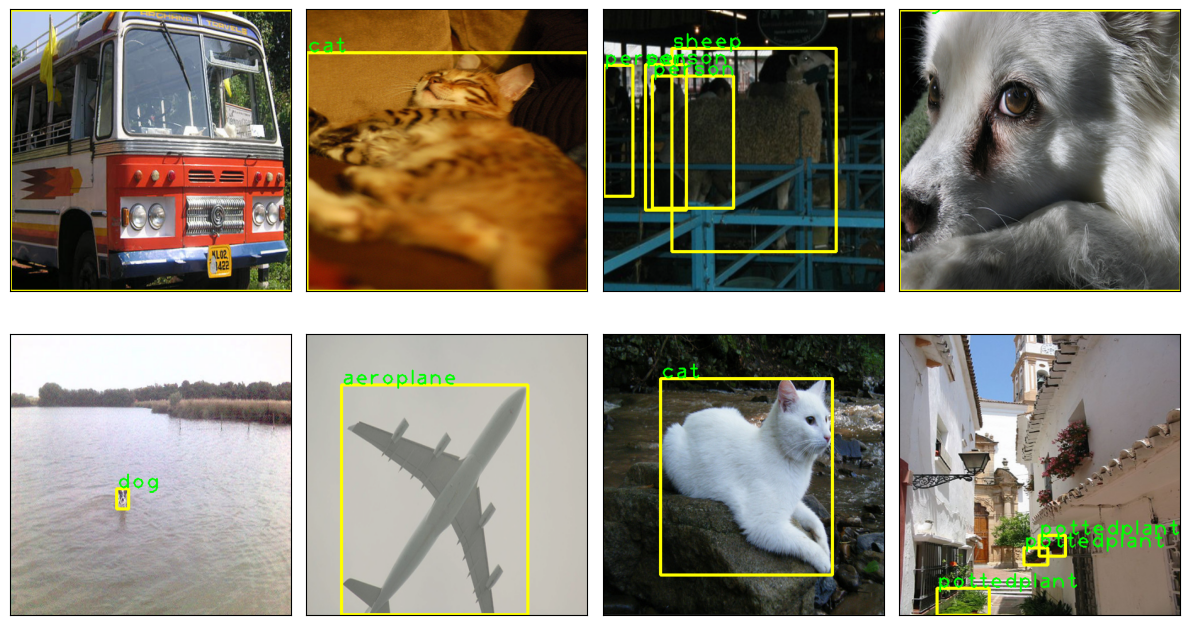

In [20]:
def visualize_images(trainloader, number_of_images=12):
    fig = plt.figure(figsize=(12,10))

    images, labels = next(iter(train_loader))

    num_rows = 3
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        # Convert to OpenCV image
        tensor_img = image.clone()

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        
        img = tensor_img.permute(1, 2, 0).cpu().numpy()  # HWC
        img = img * std + mean
        img = np.clip(img, 0, 1)
        img = (img * 255).astype(np.uint8)
        img = np.ascontiguousarray(img)
        #img = (img - img.min())/ (img.max() - img.min())

        
        
        #'size': {'width': '500', 'height': '442', 'depth': '3'}

        orig_w = int(label['annotation']['size']['width'])
        orig_h = int(label['annotation']['size']['height'])
        new_w = 448
        new_h = 448

        scale_x = new_w / orig_w
        scale_y = new_h / orig_h

        for obj_element in label['annotation']['object']:
            x_min = int(int(obj_element['bndbox']['xmin']) * scale_x)
            y_min = int(int(obj_element['bndbox']['ymin']) * scale_y)
            x_max = int(int(obj_element['bndbox']['xmax']) * scale_x)
            y_max = int(int(obj_element['bndbox']['ymax']) * scale_y)
            
            cv2.rectangle(img, (x_min, y_min), (x_max, y_max) , (255, 255, 0), thickness=3, lineType=cv2.LINE_8)
            cv2.putText(img, obj_element['name'], (x_min,y_min),fontFace=cv2.FONT_HERSHEY_PLAIN, fontScale=2.3, color=(0,255,0), thickness=2)        
       
        ax.imshow(img, cmap='gray')

        #ax.set_title(f"{label.item()}: {train_data.classes[label.item()]}")

    fig.tight_layout()
    #plt.savefig('voc_dataset.pdf', dpi=300, bbox_inches="tight")
    plt.show()
visualize_images(train_loader)


#### YOLO ResNet

In [21]:
class YoloResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        resnet = models.resnet34(
            weights=models.ResNet34_Weights.DEFAULT
        )

        self.backbone = nn.Sequential(
            *list(resnet.children())[:-2]
        )  # output: [B, 512, H/32, W/32]

        # Additional convolution layers
        self.extra_conv = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=64, kernel_size=1, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(64, 1024, kernel_size=3, stride = 2, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=1024, out_channels=64, kernel_size=1, padding=0),
            nn.BatchNorm2d(64),
            
           
            nn.Conv2d(64, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=512, out_channels=64, kernel_size=1, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
           

            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=256, out_channels=64, kernel_size=1, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        #self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(in_features=128*7*7, out_features=4096),                            # Linear 1
            nn.Dropout(p=0.2),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=4096, out_features= 1470)
        )

    def forward(self, x):
        x = self.backbone(x)      # [B,2048,H,W]
        x = self.extra_conv(x)    # [B,128,H,W]
        #x = self.pool(x)          # [B,128,1,1]
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

In [22]:
model = YoloResNet()

model.load_state_dict(torch.load("best_res_52_iteration.pt",  map_location=DEVICE))

for param in model.backbone.parameters():
    param.requires_grad = True


model = model.to(DEVICE)

#optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate)
optimizer = torch.optim.Adam( filter(lambda p: p.requires_grad, model.parameters()), lr= train_config.learning_rate, weight_decay=.0001)

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (8,3,448,448)

print(summary(model, dummy_input, row_settings=["var_names"], device='cuda'))

Layer (type (var_name))                       Output Shape              Param #
YoloResNet (YoloResNet)                       [8, 1470]                 --
├─Sequential (backbone)                       [8, 512, 14, 14]          --
│    └─Conv2d (0)                             [8, 64, 224, 224]         9,408
│    └─BatchNorm2d (1)                        [8, 64, 224, 224]         128
│    └─ReLU (2)                               [8, 64, 224, 224]         --
│    └─MaxPool2d (3)                          [8, 64, 112, 112]         --
│    └─Sequential (4)                         [8, 64, 112, 112]         --
│    │    └─BasicBlock (0)                    [8, 64, 112, 112]         73,984
│    │    └─BasicBlock (1)                    [8, 64, 112, 112]         73,984
│    │    └─BasicBlock (2)                    [8, 64, 112, 112]         73,984
│    └─Sequential (5)                         [8, 128, 56, 56]          --
│    │    └─BasicBlock (0)                    [8, 128, 56, 56]          230,144

In [30]:
for param in model.backbone.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam( filter(lambda p: p.requires_grad, model.parameters()), lr= 0.001*train_config.learning_rate, weight_decay=.000001)

#### Define Loss Function

In [24]:
class BBBox:
    def __init__(self, xmin, ymin, xmax, ymax):
        self.xmin = xmin
        self.ymin = ymin
        self.xmax = xmax
        self.ymax = ymax
        
    def is_inside(self, x, y):
        if self.xmin <= x and self.ymin <= y and x <= self.xmax and y <= self.ymax:
            return True
        else:
            return False

    def get_corner(self):
        corner = []
        corner.append([self.xmin,self.ymin])
        corner.append([self.xmax,self.ymin])
        corner.append([self.xmax,self.ymax])
        corner.append([self.xmin,self.ymax])
        return corner

    def calculate_area(self, corner):
        return abs(corner[0][0] - corner[1][0]) * abs(corner[0][1] - corner[3][1])
        
class IOU:
    def __init__(self, bb_box_1, bb_box_2):
        self.bb_box_1 = bb_box_1
        self.bb_box_2 = bb_box_2

    def find_intersection_area(self):
        x_left = max(self.bb_box_1.xmin, self.bb_box_2.xmin)
        y_top = max(self.bb_box_1.ymin, self.bb_box_2.ymin)

        x_right = min(self.bb_box_1.xmax, self.bb_box_2.xmax)
        y_bottom = min(self.bb_box_1.ymax, self.bb_box_2.ymax)

        if x_right <= x_left or y_bottom <= y_top:
            return 0.0

        return (x_right - x_left) * (y_bottom - y_top)

    def calculate_iou(self):
        intersection_area = self.find_intersection_area()

        area1 = self.bb_box_1.calculate_area(
            self.bb_box_1.get_corner()
        )
        area2 = self.bb_box_2.calculate_area(
            self.bb_box_2.get_corner()
        )

        union = area1 + area2 - intersection_area

        return intersection_area / union if union > 0 else 0.0

In [86]:
class Loss:
    def __init__(self, label):
        self.label = label
        self.img_w = 448
        self.img_h = 448
        self.objects = []
        self.objects_indicator = None
        self.lamba_nobj = .5
        self.lamba_coord = 5.    
        self.S = 7
        self.B = 2

        self.setup()

    def setup(self):
        self.get_rescaled_coordinate()
        self.get_objects_indicator()

    def get_objects_indicator(self):
        self.objects_indicator = {(i,j):(False,(),'') for i in range(7) for j in range(7)}
        for coordinate in self.objects:
            x_c = (coordinate[0] + coordinate[2]) / 2
            y_c = (coordinate[1] + coordinate[3]) / 2
            self.objects_indicator[(int(y_c/64), int(x_c/64))] = (True, (coordinate[0], coordinate[1], coordinate[2], coordinate[3]), coordinate[4])
    
    def get_rescaled_coordinate(self):
        orig_w = int(self.label['annotation']['size']['width'])
        orig_h = int(self.label['annotation']['size']['height'])
        
        scale_x = self.img_w / orig_w
        scale_y = self.img_h / orig_h

        self.objects = []
        for obj_element in self.label['annotation']['object']:
            x_min = int(int(obj_element['bndbox']['xmin']) * scale_x)
            y_min = int(int(obj_element['bndbox']['ymin']) * scale_y)
            x_max = int(int(obj_element['bndbox']['xmax']) * scale_x)
            y_max = int(int(obj_element['bndbox']['ymax']) * scale_y)

            self.objects.append((x_min, y_min, x_max, y_max, obj_element['name']))

    def calculate_iou(self, coordinate, data, i, j):
        conf_iou = []
        box_gt = BBBox(coordinate[0],coordinate[1], coordinate[2], coordinate[3])
        for b in range(self.B):
            #penalizes bounding box coordinate error if that predictor is “responsible” for the ground truth box 
            #(i.e. has the highest IOU of any predictor in that grid cell).
            x,y,w,h,c = data[b*5:(b+1)*5].detach()
           
            x_c = (j*64) +  (x*64)
            y_c = (i*64) +  (y*64)
           
            x_top_left = x_c - ((torch.clamp(w, min=0.0) * self.img_w)/2)
            y_top_left = y_c - ((torch.clamp(h, min=0.0) * self.img_h)/2)
            x_bottom_right = x_c + ((torch.clamp(w, min=0.0) * self.img_w)/2)
            y_bottom_right = y_c + ((torch.clamp(h, min=0.0) * self.img_h)/2)
            
            box_predicted = BBBox(x_top_left, y_top_left, x_bottom_right, y_bottom_right)
            iou = IOU(bb_box_1= box_gt, bb_box_2=box_predicted)
            conf_iou.append(iou.calculate_iou())
        return conf_iou

    def calculate_class_loss(self, class_name, data, device):
        
         # Class Loss
        one_hot = F.one_hot(torch.tensor(classes_idx[class_name], device=device), num_classes=len(classes_idx)).float()
        return torch.sum((one_hot - data[10:30])**2)

    def calculate_loss(self, output):
        self.loss = torch.zeros(1, device=output.device)
        """The confidence prediction represents the IOU between the predicted box and any ground truth box."""
        for i in range(self.S):
            for j in range(self.S):
                final_layer_start_idx = ((i*self.S) + j)*30
                final_layer_end_idx = ((i*self.S) + j + 1)*30
                data = output[final_layer_start_idx: final_layer_end_idx]
                is_obj, coordinate, class_name = self.objects_indicator[(i,j)]
                if is_obj:   
                    conf_iou = self.calculate_iou(coordinate, data, i, j)
                    conf_iou = torch.tensor(conf_iou, device=output.device)
                    
                    # Responsible Bounding box confidence loss
                    responsible_box_idx = conf_iou.argmax().item()
    
                    responsible_box_target = conf_iou.max()
                    x,y,w,h,c = data[responsible_box_idx*5:(responsible_box_idx+1)*5]
                    self.loss += (c - responsible_box_target)**2

                    # Coordinate offset loss
                    x_c = (coordinate[0] + coordinate[2]) / 2
                    x_offset = (x_c - (j*64)) / 64
                    y_c = (coordinate[1] + coordinate[3]) / 2
                    y_offset = (y_c - (i*64)) / 64

                    self.loss += self.lamba_coord * ((x_offset - x)**2 + (y_offset - y)**2)

                    # Coordinate width and hight loss
                    w_gt = (coordinate[2] - coordinate[0]) / self.img_w
                    h_gt = (coordinate[3] - coordinate[1]) / self.img_h

                    w_gt = torch.as_tensor(w_gt, device=output.device)
                    h_gt = torch.as_tensor(h_gt, device=output.device)

                    self.loss += self.lamba_coord * ((torch.sqrt(torch.clamp(w, min=1e-6)) - torch.sqrt(w_gt))**2 + \
                                             ((torch.sqrt(torch.clamp(h, min=1e-6))) - torch.sqrt(h_gt))**2)
            
                    # Non-Responsible Bounding box confidence loss
                    non_responsible_box_idx = conf_iou.argmin().item()
                    x_noobj,y_noobj,w_nobj,h_noobj,c_noobj = data[non_responsible_box_idx*5:(non_responsible_box_idx+1)*5]
                    self.loss += self.lamba_nobj * (0.0 - c_noobj)**2

                    self.loss += self.calculate_class_loss(class_name, data, output.device)    
        
                else:
                    for b in range(self.B):
                        #penalizes bounding box coordinate error if that predictor is “responsible” for the ground truth box 
                        #(i.e. has the highest IOU of any predictor in that grid cell).
                        x,y,w,h,c = data[b*5:(b+1)*5]
                        self.loss += self.lamba_nobj * (0.0 - c)**2
        return self.loss

class BatchLoss:
    def __init__(self, outputs, labels):
        self.outputs = outputs
        self.labels = labels

    def calculate_mse(self):
        self.mse = torch.zeros(1, device=self.outputs.device)
        for i in range(len(self.outputs)):
            a = Loss(self.labels[i])
            #print(a.objects)
            self.mse += a.calculate_loss(self.outputs[i])
        return self.mse / len(self.outputs)

#### Model Training and Evaluation

In [26]:
def train(model, train_loader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model = model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):

        images = torch.stack(images)
        images = images.to(DEVICE)
    
        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)
        
        
        # Object detection loss
        object_detection_loss = BatchLoss(outputs, labels)

        loss = object_detection_loss.calculate_mse()

        running_loss += loss.item()
    
        loss.backward()

        optimizer.step()
  
        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += len(labels)

        #correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)

    #accuracy = 100 * correct_prediction/ total_samples

    accuracy = 100

    return avg_loss, accuracy

In [27]:
def validation(model, val_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = torch.stack(images)
            images = images.to(DEVICE)

            outputs = model(images)

            # Object detection loss
            object_detection_loss = BatchLoss(outputs, labels)

            loss = object_detection_loss.calculate_mse()

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += len(labels)
            
            #correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

        accuracy = 100

    return avg_loss, accuracy 

In [28]:
def main(model, trainloader, val_loader, DEVICE='cuda'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        print(epoch)
        train_loss, train_accuracy = train(model,trainloader, optimizer, DEVICE)
        #val_loss, val_accuracy = validation(model, val_loader, DEVICE)
        val_loss,  val_accuracy = 4.0, 100 

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best.pt")
            

    return train_losses, val_losses, train_accuracies, val_accuracies

In [31]:
train_losses, val_losses, train_accuracies, val_accuracies = main(model, train_loader, val_loader, DEVICE)

0


Training: 100%|██████████| 715/715 [10:01<00:00,  1.19it/s]


Epoch 1 - Train loss: 0.9657280020363681 Train accuracy: 100 %%% Val loss: 4.0 Val accuracy: 100
Saving the model... 
1


Training: 100%|██████████| 715/715 [10:28<00:00,  1.14it/s]


Epoch 2 - Train loss: 0.959576701826149 Train accuracy: 100 %%% Val loss: 4.0 Val accuracy: 100
2


...

Epoch 4 - Train loss: 0.9502193546170121 Train accuracy: 100 %%% Val loss: 4.0 Val accuracy: 100
4


Training: 100%|██████████| 715/715 [10:34<00:00,  1.13it/s]


Epoch 5 - Train loss: 0.9495458254864165 Train accuracy: 100 %%% Val loss: 4.0 Val accuracy: 100
5


Training:   3%|▎         | 20/715 [00:18<11:00,  1.05it/s]


KeyboardInterrupt: 

In [160]:
images, labels = next(iter(train_loader))

In [161]:
optimizer.zero_grad()
images = torch.stack(images)
images = images.to(DEVICE)
outputs = model(images)

In [162]:
outputs

tensor([[ 0.1631,  0.4026,  0.0326,  ...,  0.0069,  0.0198,  0.0087],
        [ 0.2289,  0.3394,  0.0306,  ...,  0.1179, -0.0070,  0.0040],
        [ 0.1706,  0.3683,  0.0223,  ..., -0.0866,  0.0088, -0.0085],
        ...,
        [ 0.2175,  0.3662,  0.0272,  ...,  0.0311, -0.0041,  0.0181],
        [ 0.1699,  0.3643,  0.0249,  ...,  0.0226, -0.0024,  0.0031],
        [ 0.1553,  0.3665,  0.0247,  ...,  0.1916, -0.0162,  0.0131]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [35]:
best_weights = model.state_dict()
torch.save(best_weights, "best_res_57_iteration.pt")

In [163]:
a = BatchLoss(outputs, labels)

a.calculate_mse()

tensor([1.5611], device='cuda:0', grad_fn=<DivBackward0>)

1 5
tensor(360.9150, device='cuda:0', grad_fn=<SubBackward0>) tensor(77.8742, device='cuda:0', grad_fn=<SubBackward0>) tensor(370.8996, device='cuda:0', grad_fn=<AddBackward0>) tensor(114.6542, device='cuda:0', grad_fn=<AddBackward0>)
yes
2 1
tensor(96.9188, device='cuda:0', grad_fn=<SubBackward0>) tensor(140.6417, device='cuda:0', grad_fn=<SubBackward0>) tensor(96.9188, device='cuda:0', grad_fn=<AddBackward0>) tensor(140.6417, device='cuda:0', grad_fn=<AddBackward0>)
yes
2 6
tensor(351.0365, device='cuda:0', grad_fn=<SubBackward0>) tensor(20.5404, device='cuda:0', grad_fn=<SubBackward0>) tensor(448.1679, device='cuda:0', grad_fn=<AddBackward0>) tensor(314.7300, device='cuda:0', grad_fn=<AddBackward0>)
4 2
tensor(63.1003, device='cuda:0', grad_fn=<SubBackward0>) tensor(161.5246, device='cuda:0', grad_fn=<SubBackward0>) tensor(316.4959, device='cuda:0', grad_fn=<AddBackward0>) tensor(443.9685, device='cuda:0', grad_fn=<AddBackward0>)
4 3
tensor(220.2324, device='cuda:0', grad_fn=<SubBac

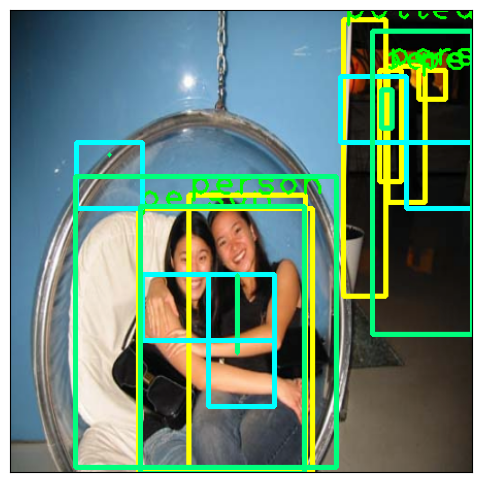

In [166]:
idx = 1

num_rows = 1
num_col = 1

fig = plt.figure(figsize=(6,6))

image, label = images[idx], labels[idx]

#Create a subplot 
ax = fig.add_subplot(num_rows, num_col, 1, xticks=[], yticks=[])

# Convert to OpenCV image
tensor_img = image.clone()
        
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
        
img = tensor_img.permute(1, 2, 0).cpu().numpy()  # HWC
img = img * std + mean
img = np.clip(img, 0, 1)
img = (img * 255).astype(np.uint8)
img = np.ascontiguousarray(img)

        
        
        #'size': {'width': '500', 'height': '442', 'depth': '3'}

orig_w = int(label['annotation']['size']['width'])
orig_h = int(label['annotation']['size']['height'])
new_w = 448
new_h = 448

scale_x = new_w / orig_w
scale_y = new_h / orig_h

for obj_element in label['annotation']['object']:
    x_min = int(int(obj_element['bndbox']['xmin']) * scale_x)
    y_min = int(int(obj_element['bndbox']['ymin']) * scale_y)
    x_max = int(int(obj_element['bndbox']['xmax']) * scale_x)
    y_max = int(int(obj_element['bndbox']['ymax']) * scale_y)
            
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max) , (255, 255, 0), thickness=3, lineType=cv2.LINE_8)
    cv2.putText(img, obj_element['name'], (x_min,y_min),fontFace=cv2.FONT_HERSHEY_PLAIN, fontScale=2.3, color=(0,255,0), thickness=2) 

S = 7
for i in range(S):
    for j in range(S):
        final_layer_start_idx = ((i*S) + j)*30
        final_layer_end_idx = ((i*S) + j + 1)*30
        x,y,w,h,c = outputs[idx][final_layer_start_idx:final_layer_end_idx][0:5]
        x1,y1,w1,h1,c1 = outputs[idx][final_layer_start_idx:final_layer_end_idx][5:10]

        if c > 0.2 and c > c1:
            print(i,j)
            cv2.rectangle(img, (j*64, i*64), ((j+1)*64, (i+1)*64) , (0, 255, 255), thickness=3, lineType=cv2.LINE_8)
            xc = (j *64) + (torch.clamp(x, min=0.0) * 64)
            yc = (i *64) + (torch.clamp(y, min=0.0) * 64)
            x_top_left = xc - ((torch.clamp(w, min=0.0)*448)/2)
            y_top_left = yc - ((torch.clamp(h, min=0.0)*448)/2)
            x_bottom_right = xc + ((torch.clamp(w, min=0.0)*448)/2)
            y_bottom_right = yc + ((torch.clamp(h, min=0.0)*448)/2)
            print(x_top_left, y_top_left, x_bottom_right, y_bottom_right)
            cv2.rectangle(img, (int(x_top_left.item()), int(y_top_left.item())), (int(x_bottom_right.item()), int(y_bottom_right.item())) , (0, 255, 125), thickness=3, lineType=cv2.LINE_8)
        elif c1 > 0.2 and c1 > c:
            print(i,j)
            cv2.rectangle(img, (j*64, i*64), ((j+1)*64, (i+1)*64) , (0, 255, 255), thickness=3, lineType=cv2.LINE_8)
            xc = (j *64) + (torch.clamp(x, min=0.0) * 64)
            yc = (i *64) + (torch.clamp(y, min=0.0) * 64)
            x_top_left = xc - ((torch.clamp(w, min=0.0)*448)/2)
            y_top_left = yc - ((torch.clamp(h, min=0.0)*448)/2)
            x_bottom_right = xc + ((torch.clamp(w, min=0.0)*448)/2)
            y_bottom_right = yc + ((torch.clamp(h, min=0.0)*448)/2)
            print(x_top_left, y_top_left, x_bottom_right, y_bottom_right)
            cv2.rectangle(img, (int(x_top_left.item()), int(y_top_left.item())), (int(x_bottom_right.item()), int(y_bottom_right.item())) , (0, 255, 125), thickness=3, lineType=cv2.LINE_8)
            print('yes')
       
ax.imshow(img, cmap='gray')

In [171]:
i = 5
j = 3
S = 7
final_layer_start_idx = ((i*S) + j)*30
final_layer_end_idx = ((i*S) + j + 1)*30

one_hot = F.one_hot(torch.tensor(classes_idx['bottle'], device=DEVICE), num_classes=len(classes_idx)).float()
print(final_layer_start_idx, final_layer_end_idx)
print(torch.sum((one_hot - outputs[idx][final_layer_start_idx+10:final_layer_end_idx])**2))
print(outputs[idx][final_layer_start_idx+10:final_layer_end_idx])
print(torch.argmax(outputs[idx][final_layer_start_idx+10:final_layer_end_idx]))

1140 1170
tensor(1.8058, device='cuda:0', grad_fn=<SumBackward0>)
tensor([ 4.1135e-03, -1.0167e-01, -3.2380e-03,  2.4090e-02,  1.1399e-01,
         2.0754e-02, -9.3390e-02,  1.9190e-02,  2.0738e-04,  3.6111e-02,
         2.1519e-02,  1.3998e-02, -3.1051e-02,  6.1556e-02,  9.8180e-01,
        -1.9136e-03,  6.4548e-03,  1.2781e-01, -2.8074e-02, -1.1191e-01],
       device='cuda:0', grad_fn=<SliceBackward0>)
tensor(14, device='cuda:0')


In [82]:
classes_idx

{'aeroplane': 0,
 'bicycle': 1,
 'bird': 2,
 'boat': 3,
 'bottle': 4,
 'bus': 5,
 'car': 6,
 'cat': 7,
 'chair': 8,
 'cow': 9,
 'diningtable': 10,
 'dog': 11,
 'horse': 12,
 'motorbike': 13,
 'person': 14,
 'pottedplant': 15,
 'sheep': 16,
 'sofa': 17,
 'train': 18,
 'tvmonitor': 19}

In [106]:
voc_colors = {
    'aeroplane':   (255,   0,   0),    # red
    'bicycle':     (255, 128,   0),    # orange
    'bird':        (255, 255,   0),    # yellow
    'boat':        (128, 255,   0),    # yellow-green
    'bottle':      (0, 255,   0),      # green
    'bus':         (0, 255, 128),      # spring green
    'car':         (0, 255, 255),      # cyan
    'cat':         (0, 128, 255),      # sky blue
    'chair':       (0,   0, 255),      # blue
    'cow':         (128,   0, 255),    # purple
    'diningtable': (255,   0, 255),    # magenta
    'dog':         (255,   0, 128),    # pink
    'horse':       (128,  64,   0),    # brown
    'motorbike':   (255, 192, 203),    # light pink
    'person':      (128, 128, 128),    # gray
    'pottedplant': (0, 128,   0),      # dark green
    'sheep':       (255, 255, 255),    # white
    'sofa':        (64, 224, 208),     # turquoise
    'train':       (75,   0, 130),     # indigo
    'tvmonitor':   (0,   0,   0),      # black
}

classes_idx_2_name = {}

for key in classes_idx:
    classes_idx_2_name[classes_idx[key]] = key

print(classes_idx_2_name)

{0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle', 5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow', 10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike', 14: 'person', 15: 'pottedplant', 16: 'sheep', 17: 'sofa', 18: 'train', 19: 'tvmonitor'}


1 5
tensor(360.9150, device='cuda:0', grad_fn=<SubBackward0>) tensor(77.8742, device='cuda:0', grad_fn=<SubBackward0>) tensor(370.8996, device='cuda:0', grad_fn=<AddBackward0>) tensor(114.6542, device='cuda:0', grad_fn=<AddBackward0>)
yes
2 1
tensor(96.9188, device='cuda:0', grad_fn=<SubBackward0>) tensor(140.6417, device='cuda:0', grad_fn=<SubBackward0>) tensor(96.9188, device='cuda:0', grad_fn=<AddBackward0>) tensor(140.6417, device='cuda:0', grad_fn=<AddBackward0>)
yes
2 6
tensor(351.0365, device='cuda:0', grad_fn=<SubBackward0>) tensor(20.5404, device='cuda:0', grad_fn=<SubBackward0>) tensor(448.1679, device='cuda:0', grad_fn=<AddBackward0>) tensor(314.7300, device='cuda:0', grad_fn=<AddBackward0>)
4 2
tensor(63.1003, device='cuda:0', grad_fn=<SubBackward0>) tensor(161.5246, device='cuda:0', grad_fn=<SubBackward0>) tensor(316.4959, device='cuda:0', grad_fn=<AddBackward0>) tensor(443.9685, device='cuda:0', grad_fn=<AddBackward0>)
4 3
tensor(220.2324, device='cuda:0', grad_fn=<SubBac

(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

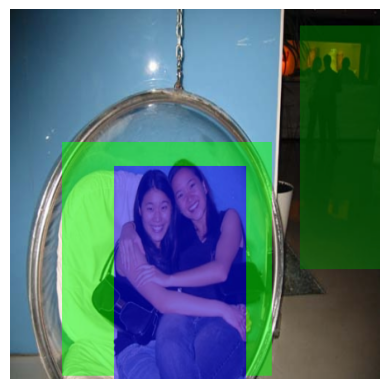

In [168]:


# Convert to OpenCV image
tensor_img = image.clone()
        
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
        
img = tensor_img.permute(1, 2, 0).cpu().numpy()  # HWC
img = img * std + mean
img = np.clip(img, 0, 1)
img = (img * 255).astype(np.uint8)
img = np.ascontiguousarray(img)

overlay = img.copy()

for i in range(S):
    for j in range(S):
        final_layer_start_idx = ((i*S) + j)*30
        final_layer_end_idx = ((i*S) + j + 1)*30

        x,y,w,h,c = outputs[idx][final_layer_start_idx:final_layer_end_idx][0:5]
        x1,y1,w1,h1,c1 = outputs[idx][final_layer_start_idx:final_layer_end_idx][5:10]

        max_class = torch.argmax(outputs[idx][final_layer_start_idx+10:final_layer_end_idx])

        if c > 0.2 and c > c1:
            print(i,j)
            xc = (j *64) + (torch.clamp(x, min=0.0) * 64)
            yc = (i *64) + (torch.clamp(y, min=0.0) * 64)
            x_top_left = xc - ((torch.clamp(w, min=0.0)*448)/2)
            y_top_left = yc - ((torch.clamp(h, min=0.0)*448)/2)
            x_bottom_right = xc + ((torch.clamp(w, min=0.0)*448)/2)
            y_bottom_right = yc + ((torch.clamp(h, min=0.0)*448)/2)
            print(x_top_left, y_top_left, x_bottom_right, y_bottom_right)
            cv2.rectangle(overlay, (int(x_top_left.item()), int(y_top_left.item())), (int(x_bottom_right.item()), int(y_bottom_right.item())) , voc_colors[max_class_name], -1)
        elif c1 > 0.2 and c1 > c:
            print(i,j)
            xc = (j *64) + (torch.clamp(x, min=0.0) * 64)
            yc = (i *64) + (torch.clamp(y, min=0.0) * 64)
            x_top_left = xc - ((torch.clamp(w, min=0.0)*448)/2)
            y_top_left = yc - ((torch.clamp(h, min=0.0)*448)/2)
            x_bottom_right = xc + ((torch.clamp(w, min=0.0)*448)/2)
            y_bottom_right = yc + ((torch.clamp(h, min=0.0)*448)/2)
            print(x_top_left, y_top_left, x_bottom_right, y_bottom_right)
            cv2.rectangle(overlay, (int(x_top_left.item()), int(y_top_left.item())), (int(x_bottom_right.item()), int(y_bottom_right.item())) , voc_colors[max_class_name], -1)
            print('yes')

        max_class_name = classes_idx_2_name[max_class.item()]

        
        

alpha = 0.5
img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

plt.imshow(img, cmap='gray')
plt.axis('off')